# CS4305 Artificial Intelligence — Lab 8
## Knowledge Representation I: Logic

**What you will learn today**
1. Use **propositions** and the connectives NOT, AND, OR, IF-THEN
2. Build **truth tables** automatically
3. Check if a knowledge base **proves** (entails) a conclusion
4. Use **Modus Ponens** to reason step by step
5. Write **predicate logic** with ∀ (for all) and ∃ (there exists)

**How to use this notebook**
- 📊 **Visual explanation** cells already show a picture. Look at the picture first, then read the code.
- 💻 **Code** cells: click inside and press **Shift + Enter** to run them, from top to bottom.
- 📝 **Lab tasks** are at the end.

In [ ]:
#@title ⚙️ Diagram tools (only needed if you want to redraw the pictures)
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, Rectangle

PURPLE, ORANGE, TEAL, ROSE, DARK = "#5B2A86", "#FF9F1C", "#1FA898", "#D1495B", "#1A1333"
LIGHT, GREY, WHITE = "#F3EEFA", "#A9A3B8", "#FFFFFF"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 12})

def tree_layout(children, root, gap=1.0):
    """Tidy layout for a tree given as {parent: [children]}."""
    pos, nxt = {}, [0.0]
    def walk(n, d):
        kids = children.get(n, [])
        if not kids:
            pos[n] = (nxt[0], -d); nxt[0] += gap
        else:
            for k in kids: walk(k, d + 1)
            xs = [pos[k][0] for k in kids]
            pos[n] = ((min(xs) + max(xs)) / 2, -d)
    walk(root, 0)
    return pos

def draw_graph(ax, pos, edges, directed=False, weights=None, colors=None, path=None, r=0.28,
               fs=13, label_below=False, badges=None, badge_color=ORANGE, edge_fs=11, names=None):
    """Draw nodes (circles) and edges. path = list of nodes to highlight in orange."""
    colors = colors or {}
    on_path = set()
    if path:
        for a, b in zip(path, path[1:]): on_path |= {(a, b), (b, a)}
    for i, (a, b) in enumerate(edges):
        (x1, y1), (x2, y2) = pos[a], pos[b]
        L = math.hypot(x2 - x1, y2 - y1); ux, uy = (x2 - x1) / L, (y2 - y1) / L
        s, e = (x1 + ux * r, y1 + uy * r), (x2 - ux * r, y2 - uy * r)
        hi = (a, b) in on_path
        ax.annotate("", xy=e, xytext=s, arrowprops=dict(arrowstyle="-|>" if directed else "-",
                    color=ORANGE if hi else GREY, lw=4 if hi else 1.8, shrinkA=0, shrinkB=0,
                    mutation_scale=18), zorder=1)
        if weights:
            w = weights[i]
            ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(w), ha="center", va="center", fontsize=edge_fs,
                    color=DARK, fontweight="bold", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.2", fc=WHITE, ec="none"))
    for n, (x, y) in pos.items():
        c = colors.get(n, PURPLE)
        ax.add_patch(Circle((x, y), r, fc=c, ec=WHITE, lw=2, zorder=3))
        text = (names or {}).get(n, n)
        if label_below:
            ax.text(x, y - r - 0.06, text, ha="center", va="top", fontsize=fs, color=DARK, fontweight="bold", zorder=5)
        else:
            ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=WHITE if c not in (ORANGE, LIGHT, WHITE) else DARK,
                    fontweight="bold", zorder=5)
    if badges:
        for n, t in badges.items():
            x, y = pos[n]
            ax.add_patch(Circle((x + r * 0.95, y + r * 0.95), r * 0.55, fc=badge_color, ec=WHITE, lw=1.5, zorder=6))
            ax.text(x + r * 0.95, y + r * 0.95, str(t), ha="center", va="center", fontsize=fs - 3,
                    color=DARK, fontweight="bold", zorder=7)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    m = r * 2.2
    ax.set_xlim(min(xs) - m, max(xs) + m); ax.set_ylim(min(ys) - m - (0.35 if label_below else 0), max(ys) + m)
    ax.set_aspect("equal"); ax.axis("off")

def box(ax, x, y, w, h, text, fc=PURPLE, tc=WHITE, fs=13, bold=True, ec=None, round_=True):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08" if round_ else "square,pad=0",
                                fc=fc, ec=ec or fc, lw=1.5, zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=tc,
            fontweight="bold" if bold else "normal", zorder=3)

def arrow(ax, x1, y1, x2, y2, color=DARK, lw=2, text=None, fs=11):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, shrinkA=0, shrinkB=0, mutation_scale=16))
    if text:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, text, ha="center", va="bottom", fontsize=fs, color=DARK)

def board(ax, x0, y0, state, size=0.9, title=None, highlight=None, fc=LIGHT):
    """Draw an 8-puzzle board. state = string like '123456780' (0 = blank)."""
    highlight = highlight or {}
    for i, ch in enumerate(state):
        r, c = divmod(i, 3)
        x, y = x0 + c * size, y0 - r * size
        blank = ch == "0"
        ax.add_patch(Rectangle((x, y), size, size, fc=WHITE if blank else highlight.get(ch, fc),
                               ec=DARK, lw=2, zorder=2))
        if not blank:
            ax.text(x + size / 2, y + size / 2, ch, ha="center", va="center", fontsize=20, fontweight="bold",
                    color=WHITE if highlight.get(ch) in (PURPLE, ROSE, TEAL) else DARK, zorder=3)
    if title:
        ax.text(x0 + 1.5 * size, y0 + size + 0.25, title, ha="center", va="bottom", fontsize=14, fontweight="bold", color=DARK)

def finish(fig, title=None):
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", color=DARK)
    fig.tight_layout()


# ---- shared data for this lab's diagrams ----
def _text_tree(ax, children, root, labels, colors=None, gap=1.6, w=1.35, h=0.5, fs=12, level_gap=1.1):
    """Draw a tree whose nodes are text boxes. labels: node-id -> text."""
    colors = colors or {}
    pos = tree_layout(children, root, gap=gap)
    pos = {k: (x, y * level_gap) for k, (x, y) in pos.items()}
    for p, ks in children.items():
        for k in ks:
            (x1, y1), (x2, y2) = pos[p], pos[k]
            ax.plot([x1, x2], [y1 - h / 2, y2 + h / 2], color=GREY, lw=1.8, zorder=1)
    for k, (x, y) in pos.items():
        fc = colors.get(k, PURPLE)
        box(ax, x - w / 2, y - h / 2, w, h, labels.get(k, k), fc=fc, tc=DARK if fc in (ORANGE, LIGHT, WHITE) else WHITE, fs=fs)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    ax.set_xlim(min(xs) - w, max(xs) + w); ax.set_ylim(min(ys) - h * 1.5, max(ys) + h * 1.5)
    ax.set_aspect("equal"); ax.axis("off")
    return pos

ZOO = [("R1", ["has_hair"], "mammal"), ("R2", ["gives_milk"], "mammal"), ("R3", ["has_feathers"], "bird"),
       ("R4", ["mammal", "eats_meat"], "carnivore"), ("R5", ["carnivore", "tawny", "dark_spots"], "cheetah"),
       ("R6", ["carnivore", "tawny", "black_stripes"], "tiger"), ("R7", ["bird", "swims", "cannot_fly"], "penguin")]

NET_POS = {"Animal": (3.5, 4), "Bird": (1.5, 2.4), "Mammal": (5.5, 2.4), "Canary": (0.3, 0.8), "Penguin": (2.7, 0.8),
           "Cow": (5.5, 0.8), "Tweety": (0.3, -0.8), "fly": (-1.2, 2.4), "feathers": (0.4, 3.7), "breathe": (6.9, 4.4),
           "milk": (7.4, 0.8), "yellow": (-1.4, 0.2)}

NET_EDGES = [("Bird", "Animal", "is-a"), ("Mammal", "Animal", "is-a"), ("Canary", "Bird", "is-a"), ("Penguin", "Bird", "is-a"),
             ("Cow", "Mammal", "is-a"), ("Tweety", "Canary", "instance"), ("Bird", "fly", "can"), ("Bird", "feathers", "has"),
             ("Animal", "breathe", "can"), ("Cow", "milk", "gives"), ("Canary", "yellow", "colour")]

def _net(ax, path=None, exception=True):
    concept = {"Animal", "Bird", "Mammal", "Canary", "Penguin", "Cow", "Tweety"}
    on = set(zip(path, path[1:])) if path else set()
    for a, b, lab in NET_EDGES:
        (x1, y1), (x2, y2) = NET_POS[a], NET_POS[b]
        hi = (a, b) in on
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="-|>", lw=4 if hi else 1.8,
                    color=ORANGE if hi else GREY, shrinkA=22, shrinkB=22, mutation_scale=16))
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, lab, fontsize=10.5, ha="center", va="center", color=DARK,
                bbox=dict(boxstyle="round,pad=0.15", fc=WHITE, ec="none"))
    if exception:
        (x1, y1), (x2, y2) = NET_POS["Penguin"], NET_POS["fly"]
        ax.annotate("", xy=(x2 + 0.3, y2 - 0.2), xytext=(x1 - 0.3, y1 + 0.1), arrowprops=dict(arrowstyle="-|>", lw=2, color=ROSE, ls="--",
                    connectionstyle="arc3,rad=-0.25", shrinkA=14, shrinkB=14))
        ax.text(0.2, 1.55, "can: NO", fontsize=10.5, color=ROSE, fontweight="bold")
    for n_, (x, y) in NET_POS.items():
        if n_ in concept:
            c = ORANGE if n_ == "Tweety" else PURPLE
            box(ax, x - 0.62, y - 0.28, 1.24, 0.56, n_, fc=c, tc=DARK if c == ORANGE else WHITE, fs=11.5)
        else:
            box(ax, x - 0.55, y - 0.25, 1.1, 0.5, n_, fc=LIGHT, tc=DARK, fs=11, bold=False)
    ax.set_xlim(-2.1, 8.1); ax.set_ylim(-1.3, 4.9); ax.set_aspect("equal"); ax.axis("off")
print('Diagram tools ready')

---
## Part 1: Why logic? (Knowledge Representation)
To reason, a computer must first **store** knowledge in a form it can use. Logic is the most exact way: every sentence is either **true** or **false**.

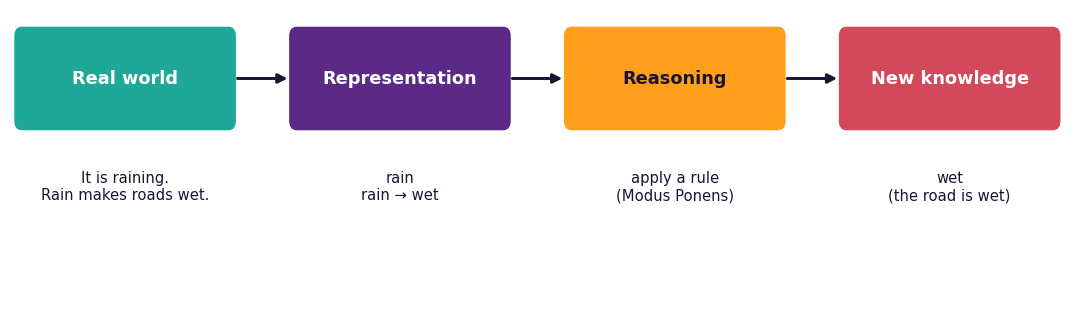

In [ ]:
#@title 📊 Visual explanation: from the real world to new knowledge
def fig_kr_idea():
    fig, ax = plt.subplots(figsize=(13, 3.8))
    steps = [("Real world", "It is raining.\nRain makes roads wet.", TEAL),
             ("Representation", "rain\nrain → wet", PURPLE),
             ("Reasoning", "apply a rule\n(Modus Ponens)", ORANGE),
             ("New knowledge", "wet\n(the road is wet)", ROSE)]
    for i, (t, ex, c) in enumerate(steps):
        x = i * 3.3
        box(ax, x, 1.5, 2.6, 0.9, t, fc=c, tc=DARK if c == ORANGE else WHITE, fs=15)
        ax.text(x + 1.3, 1.1, ex, ha="center", va="top", fontsize=12.5, color=DARK)
        if i < 3:
            arrow(ax, x + 2.65, 1.95, x + 3.25, 1.95, lw=2.5)
    ax.set_xlim(-0.1, 12.8); ax.set_ylim(-0.1, 2.6); ax.axis("off")
    finish(fig)
    return fig

fig_kr_idea()
plt.show()

---
## Part 2: Propositions and connectives
A **proposition** is a sentence that is true or false: *"It is raining."*

| Symbol | Name | Read as |
|---|---|---|
| ¬P | NOT | not P |
| P ∧ Q | AND | P and Q |
| P ∨ Q | OR | P or Q (or both) |
| P → Q | IMPLIES | if P then Q |
| P ↔ Q | IFF | P if and only if Q |

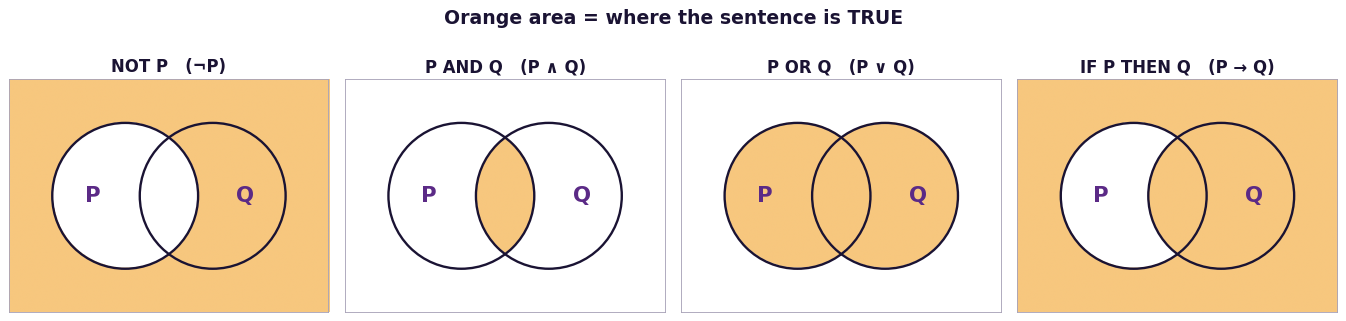

In [ ]:
#@title 📊 Visual explanation: where each connective is TRUE
def fig_venn():
    xx, yy = np.meshgrid(np.linspace(-2.2, 2.2, 400), np.linspace(-1.6, 1.6, 300))
    P = (xx + 0.6) ** 2 + yy ** 2 < 1.0
    Q = (xx - 0.6) ** 2 + yy ** 2 < 1.0
    cases = [("NOT P   (¬P)", ~P), ("P AND Q   (P ∧ Q)", P & Q), ("P OR Q   (P ∨ Q)", P | Q), ("IF P THEN Q   (P → Q)", ~P | Q)]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
    from matplotlib.colors import ListedColormap
    for ax, (t, mask) in zip(axes, cases):
        ax.imshow(mask, extent=(-2.2, 2.2, -1.6, 1.6), cmap=ListedColormap([WHITE, "#F7C77E"]), origin="lower")
        for cx, lab in [(-0.6, "P"), (0.6, "Q")]:
            ax.add_patch(Circle((cx, 0), 1.0, fill=False, ec=DARK, lw=2))
            ax.text(cx + (-0.45 if lab == "P" else 0.45), 0, lab, fontsize=18, fontweight="bold", ha="center", va="center", color=PURPLE)
        ax.add_patch(Rectangle((-2.2, -1.6), 4.4, 3.2, fill=False, ec=GREY, lw=1.5))
        ax.set_title(t, fontsize=14, fontweight="bold", color=DARK)
        ax.set_aspect("equal"); ax.axis("off")
    finish(fig, "Orange area = where the sentence is TRUE")
    return fig

fig_venn()
plt.show()

In [ ]:
# ===== Propositions are just True / False =====
rain = True          # "It is raining"
cold = False         # "It is cold"

print("NOT rain      :", not rain)
print("rain AND cold :", rain and cold)
print("rain OR cold  :", rain or cold)

def implies(p, q):
    """P → Q is FALSE only when P is True and Q is False."""
    return (not p) or q

def iff(p, q):
    """P ↔ Q is True when both have the same value."""
    return p == q

print("rain → cold   :", implies(rain, cold))
print("rain ↔ cold   :", iff(rain, cold))

---
## Part 3: Truth tables
A truth table lists **every possible combination** of true/false values. With 2 propositions there are 2 × 2 = 4 rows.

In [ ]:
# ===== A truth-table generator =====
from itertools import product

def truth_table(sentence, names, title):
    print(title)
    print("  ".join(f"{n:^5}" for n in names), "|", "result")
    print("-" * (7 * len(names) + 9))
    for values in product([True, False], repeat=len(names)):
        env = dict(zip(names, values))
        row = "  ".join(f"{'T' if v else 'F':^5}" for v in values)
        print(row, "|", "  T" if sentence(**env) else "  F")
    print()

truth_table(lambda P, Q: P and Q, ["P", "Q"], "P ∧ Q  (AND)")
truth_table(lambda P, Q: P or Q, ["P", "Q"], "P ∨ Q  (OR)")
truth_table(lambda P, Q: implies(P, Q), ["P", "Q"], "P → Q  (IF P THEN Q)")

### The tricky one: IF-THEN
Think of **P → Q** as a **promise**. It is only broken when P happens but Q does not.

In [ ]:
# ===== Understanding IF-THEN with a promise =====
# Teacher's promise: "IF you get 90% (P) THEN you get a prize (Q)"
cases = [(True, True, "got 90%, got prize"), (True, False, "got 90%, NO prize"),
         (False, True, "did not get 90%, got prize anyway"), (False, False, "did not get 90%, no prize")]
for p, q, story in cases:
    verdict = "promise kept" if implies(p, q) else "PROMISE BROKEN"
    print(f"{story:36s} → P→Q = {implies(p, q)!s:5}  ({verdict})")
print("\nThe promise is only broken in ONE case: P is true but Q is false.")

---
## Part 4: Tautology, contradiction, equivalence
- **Tautology**: always true (e.g. *"it is raining or it is not raining"*)
- **Contradiction**: always false
- Two sentences are **equivalent** if they have the same truth table (e.g. De Morgan's law)

In [ ]:
# ===== Tautology, contradiction, or contingent? =====
def classify(sentence, names):
    results = [sentence(**dict(zip(names, v))) for v in product([True, False], repeat=len(names))]
    if all(results):  return "TAUTOLOGY (always true)"
    if not any(results): return "CONTRADICTION (always false)"
    return "CONTINGENT (sometimes true)"

print("P ∨ ¬P          :", classify(lambda P: P or not P, ["P"]))
print("P ∧ ¬P          :", classify(lambda P: P and not P, ["P"]))
print("P → Q           :", classify(lambda P, Q: implies(P, Q), ["P", "Q"]))

# Two sentences are EQUIVALENT if they always have the same value
de_morgan = lambda P, Q: iff(not (P and Q), (not P) or (not Q))
print("De Morgan ¬(P∧Q) ↔ (¬P∨¬Q):", classify(de_morgan, ["P", "Q"]))
contra = lambda P, Q: iff(implies(P, Q), implies(not Q, not P))
print("(P→Q) ↔ (¬Q→¬P)          :", classify(contra, ["P", "Q"]))

---
## Part 5: Does the knowledge base prove the goal?
**KB ⊨ goal** ("KB entails goal") means: *in every situation where the KB is true, the goal is also true.* We simply check all rows.

In [ ]:
# ===== Does the knowledge base prove the goal? (model checking) =====
# KB:  Rain → Wet,   Rain.        Goal: Wet
def KB(Rain, Wet):
    return implies(Rain, Wet) and Rain

def goal(Rain, Wet):
    return Wet

print(" Rain   Wet  | KB true? | goal true?")
entailed = True
for Rain, Wet in product([True, False], repeat=2):
    kb, g = KB(Rain, Wet), goal(Rain, Wet)
    print(f"  {Rain!s:5} {Wet!s:5} |  {kb!s:6}  |  {g}", "  ← KB is true here" if kb else "")
    if kb and not g:
        entailed = False
print("\nKB entails 'Wet'?", entailed, " (goal is true in EVERY row where KB is true)")

---
## Part 6: Inference rules
Instead of checking every row, we can use **rules of inference** that always give correct conclusions.

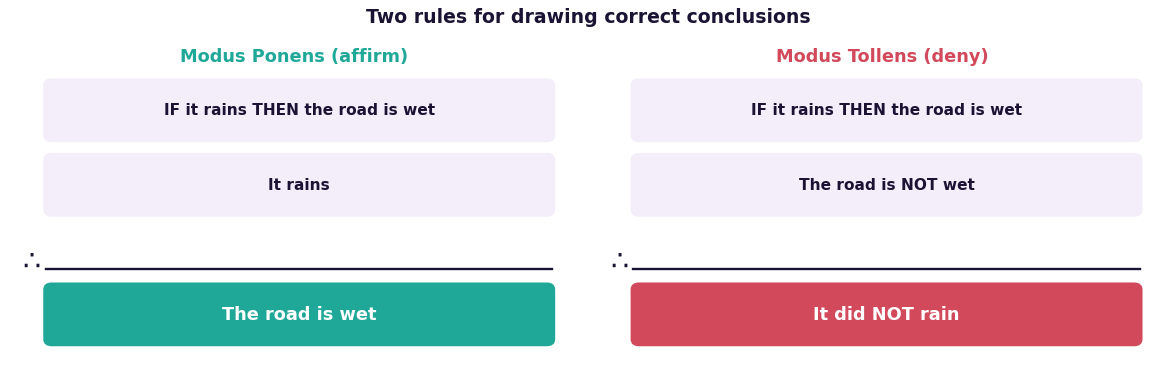

In [ ]:
#@title 📊 Visual explanation: Modus Ponens and Modus Tollens
def fig_modus():
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
    data = [("Modus Ponens (affirm)", ["IF it rains THEN the road is wet", "It rains"], "The road is wet", TEAL),
            ("Modus Tollens (deny)", ["IF it rains THEN the road is wet", "The road is NOT wet"], "It did NOT rain", ROSE)]
    for ax, (t, prem, concl, c) in zip(axes, data):
        for i, pr in enumerate(prem):
            box(ax, 0.3, 2.6 - i * 0.95, 5.4, 0.75, pr, fc=LIGHT, tc=DARK, fs=13)
        ax.plot([0.3, 5.7], [0.95, 0.95], color=DARK, lw=2)
        ax.text(0.05, 1.05, "∴", fontsize=24, color=DARK, va="center")
        box(ax, 0.3, 0.0, 5.4, 0.75, concl, fc=c, fs=15)
        ax.set_title(t, fontsize=15, fontweight="bold", color=c)
        ax.set_xlim(-0.1, 6); ax.set_ylim(-0.2, 3.5); ax.axis("off")
    finish(fig, "Two rules for drawing correct conclusions")
    return fig

fig_modus()
plt.show()

In [ ]:
# ===== Reasoning with Modus Ponens, again and again =====
facts = {"exam_tomorrow"}
rules = [("exam_tomorrow", "study_tonight"), ("study_tonight", "sleep_late"), ("sleep_late", "drink_tea")]

changed = True
while changed:
    changed = False
    for p, q in rules:
        if p in facts and q not in facts:
            print(f"Modus Ponens:  {p} → {q}  and  {p}   ⇒   {q}")
            facts.add(q); changed = True
print("\nAll facts now:", facts)

### Resolution and the sympy library
**Resolution** proves a goal by showing that its **opposite** leads to a contradiction. First every sentence is changed into **clauses** (CNF: ORs joined by ANDs).

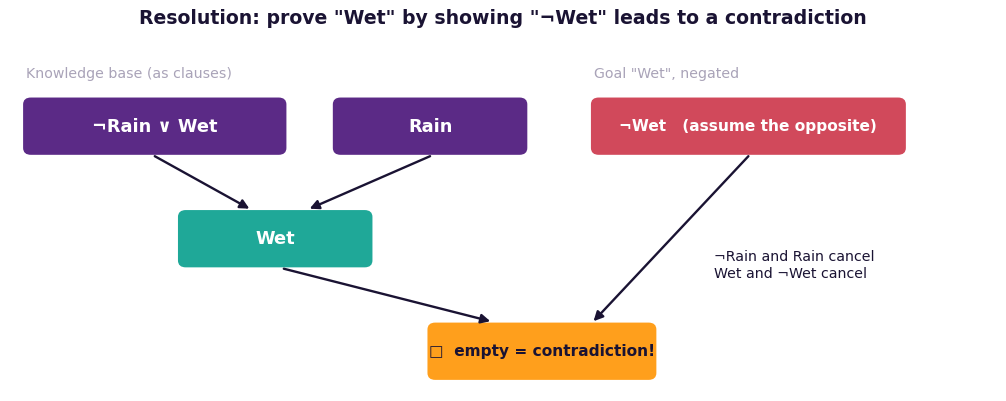

In [ ]:
#@title 📊 Visual explanation: proof by contradiction
def fig_resolution():
    fig, ax = plt.subplots(figsize=(12, 4.8))
    box(ax, 0.2, 3.2, 3.0, 0.7, "¬Rain ∨ Wet", fc=PURPLE, fs=15)
    box(ax, 3.8, 3.2, 2.2, 0.7, "Rain", fc=PURPLE, fs=15)
    box(ax, 6.8, 3.2, 3.6, 0.7, "¬Wet   (assume the opposite)", fc=ROSE, fs=13)
    box(ax, 2.0, 1.7, 2.2, 0.7, "Wet", fc=TEAL, fs=15)
    box(ax, 4.9, 0.2, 2.6, 0.7, "□  empty = contradiction!", fc=ORANGE, tc=DARK, fs=13)
    arrow(ax, 1.7, 3.15, 2.8, 2.45); arrow(ax, 4.9, 3.15, 3.5, 2.45)
    arrow(ax, 3.2, 1.65, 5.6, 0.95); arrow(ax, 8.6, 3.15, 6.8, 0.95)
    ax.text(0.2, 4.2, "Knowledge base (as clauses)", fontsize=12, color=GREY); ax.text(6.8, 4.2, "Goal \"Wet\", negated", fontsize=12, color=GREY)
    ax.text(8.2, 1.7, "¬Rain and Rain cancel\nWet and ¬Wet cancel", fontsize=12, color=DARK, va="center")
    ax.set_xlim(0, 11.5); ax.set_ylim(0, 4.6); ax.axis("off")
    finish(fig, "Resolution: prove \"Wet\" by showing \"¬Wet\" leads to a contradiction")
    return fig

fig_resolution()
plt.show()

In [ ]:
# ===== The sympy library does logic for us =====
from sympy import symbols
from sympy.logic.boolalg import Implies, And, Or, Not, to_cnf, simplify_logic
from sympy.logic.inference import satisfiable

Rain, Wet, Cold = symbols("Rain Wet Cold")
sentence = Implies(Rain, Wet)
print("Rain → Wet in CNF (clause form):", to_cnf(sentence))
print("Simplify (P ∧ Q) ∨ (P ∧ ¬Q):", simplify_logic(Or(And(Rain, Wet), And(Rain, Not(Wet)))))

# Proof by contradiction (the idea behind RESOLUTION):
kb = And(Implies(Rain, Wet), Rain)
print("\nIs  KB ∧ ¬Wet  possible?", satisfiable(And(kb, Not(Wet))))
print("False means impossible, so the KB PROVES Wet.")

---
## Part 7: Predicate (first-order) logic
Propositional logic cannot say *"ALL students study"* without writing one sentence per student. Predicate logic adds **objects**, **predicates** and **quantifiers**:
- **∀x** = *for all x*  → usually used with **→**
- **∃x** = *there exists an x* → usually used with **∧**

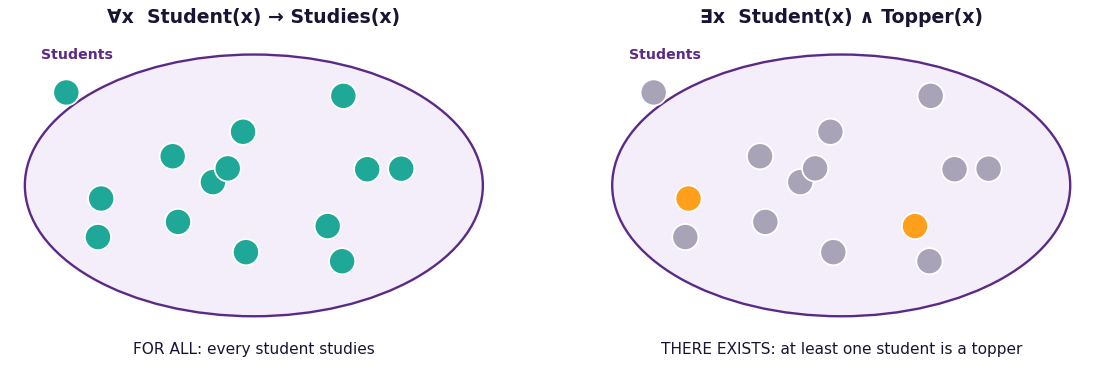

In [ ]:
#@title 📊 Visual explanation: for all vs there exists
def fig_quantifiers():
    rng = np.random.default_rng(3)
    pts = rng.uniform(-1, 1, (14, 2)) * [2.3, 1.2]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    for ax, t, sub, some in [(axes[0], "∀x  Student(x) → Studies(x)", "FOR ALL: every student studies", False),
                             (axes[1], "∃x  Student(x) ∧ Topper(x)", "THERE EXISTS: at least one student is a topper", True)]:
        from matplotlib.patches import Ellipse
        ax.add_patch(Ellipse((0, 0), 5.6, 3.2, fc=LIGHT, ec=PURPLE, lw=2))
        for i, (x, y) in enumerate(pts):
            c = ORANGE if (some and i in (2, 9)) else (TEAL if not some else GREY)
            ax.add_patch(Circle((x, y), 0.16, fc=c, ec=WHITE, lw=1.5))
        ax.text(-2.6, 1.55, "Students", fontsize=12, color=PURPLE, fontweight="bold")
        ax.set_title(t, fontsize=16, fontweight="bold", color=DARK, family="DejaVu Sans")
        ax.text(0, -2.05, sub, ha="center", fontsize=13, color=DARK)
        ax.set_xlim(-3, 3); ax.set_ylim(-2.3, 1.9); ax.set_aspect("equal"); ax.axis("off")
    finish(fig)
    return fig

fig_quantifiers()
plt.show()

In [ ]:
# ===== Predicate logic: objects, predicates and quantifiers =====
people   = {"ali", "sara", "usman", "ayesha", "bilal"}
student  = {"ali", "sara", "usman", "ayesha"}
studies  = {"ali", "sara", "usman", "ayesha"}
topper   = {"sara"}
teacher  = {"bilal"}
teaches  = {("bilal", "ali"), ("bilal", "sara"), ("bilal", "usman"), ("bilal", "ayesha")}

# ∀x Student(x) → Studies(x)      "every student studies"
print("∀x Student(x) → Studies(x):", all(implies(x in student, x in studies) for x in people))
# ∃x Student(x) ∧ Topper(x)       "some student is a topper"
print("∃x Student(x) ∧ Topper(x):", any(x in student and x in topper for x in people))
# ∀x Student(x) → Topper(x)       "every student is a topper"
print("∀x Student(x) → Topper(x):", all(implies(x in student, x in topper) for x in people))
# ∀x Student(x) → ∃y Teaches(y, x)   "every student has a teacher"
print("∀x Student(x) → ∃y Teaches(y,x):",
      all(implies(x in student, any((y, x) in teaches for y in people)) for x in people))

### The famous Socrates example
**All men are mortal. Socrates is a man. Therefore Socrates is mortal.** We replace x with a real object (*universal instantiation*) and then use Modus Ponens.

In [ ]:
# ===== Universal instantiation + Modus Ponens =====
# Rule:  ∀x Man(x) → Mortal(x)        Facts: Man(socrates), Man(ali)
facts = [("Man", "socrates"), ("Man", "ali"), ("City", "lahore")]
rule_if, rule_then = "Man", "Mortal"

for pred, obj in list(facts):
    if pred == rule_if:
        print(f"Put x = {obj}:  Man({obj}) → Mortal({obj}).  We know Man({obj}),  so  Mortal({obj}).")
        facts.append((rule_then, obj))
print("\nFacts:", facts)

---
## 📝 Lab Tasks
1. Make the truth table of **(P ∧ Q) → R** (3 propositions, 8 rows).
2. Check whether **P → Q** and **Q → P** are equivalent. What does this tell you?
3. KB: *"If it is Friday, there is Jummah prayer. If there is Jummah prayer, the class ends early. It is Friday."* Does the KB prove *"the class ends early"*? Use both the model-checking method and sympy.
4. Translate into predicate logic and test in Python: *"Some teacher teaches every student."*
5. **Think:** why is "∀x Student(x) ∧ Studies(x)" a WRONG translation of *"every student studies"*?